In [1]:
# Core scverse libraries
import scanpy as sc
import anndata as ad

# Data retrieval
# import pooch

#Import numpy
import numpy as np

# Load data using the sc.read_10x_mtx function
# Documentation: https://scanpy.readthedocs.io/en/stable/generated/scanpy.read_10x_mtx.html
data_source = '/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/Data/20260207_adata_preprocessed_full.h5ad'
adata = sc.read_h5ad(data_source)
 
print(adata)
print(type(adata))
adata_dense = adata.X.toarray()

print(type(adata_dense))

# To get the dimensions (rows, columns)
print(adata_dense.shape)

/Users/alanxie/miniconda3/envs/decipher_env/lib/python3.11/site-packages/torch/cuda/__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


AnnData object with n_obs × n_vars = 695260 × 423
    obs: 'centroid_x', 'centroid_y', 'centroid_z', 'fov', 'cluster', 'volume', 'population', 'cell_num', 'Unnamed: 0', 'sample_num', 'sample_id', 'sample_type', 'TMA', 'batch', 'log10_total_counts', 'leiden', 'density_status', 'atypical', 'deviation_score', 'log_lib_size', 'cell_type', 'TMA_ID', 'OS_days', 'survival sample date to death (days)', 'treatment_(0= no treatment before biopsy; 1=treatment before biopsy)', 'biopsy_site', 'biopsy_site_classification (0 = unkwn; 1 = head and neck; 2 = thoracic; 3 = non-head and neck or thoracic; 4 = LN)', 'sample site: primary vs met', 'primary site classification (0 = unkwn; 1 = head and neck; 2 = thoracic; 3 = non-head and neck or thoracic)', 'age_(yrs)', 'sex', 'PDL1 (TPS%)', 'PDL1: 0 = <1%; 1 = >=1%', 'NUT-fusion: 0 = unkwn; 1 = BRD4-NUT; 2 = BRD3-NUT; 3 = NSD3-NUT; 4 = ZNF532-NUT; 5 = ZNF592-NUT', 'note:', 'Registry participant? (YES/n)', 'NC registry ID', 'accession no.', 'treatment_status

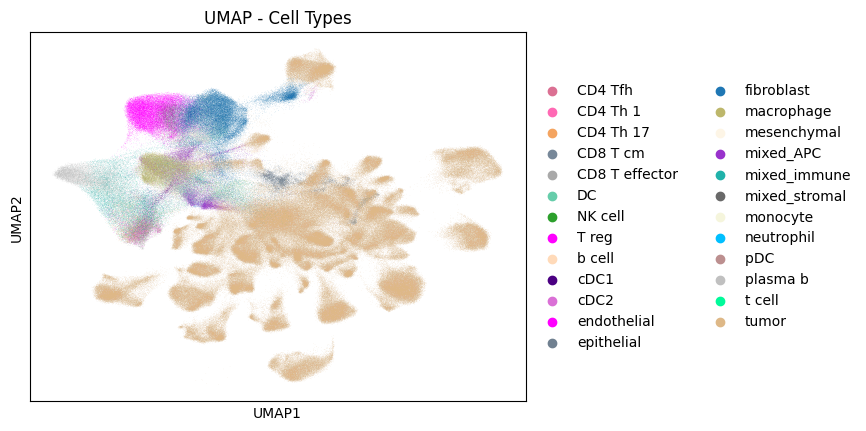

In [2]:
# Plot UMAP by cell type
sc.pl.umap(adata, color='cell_type', title="UMAP - Cell Types")

In [3]:
# What other columns are available?
print(adata.obs.columns)

Index(['centroid_x', 'centroid_y', 'centroid_z', 'fov', 'cluster', 'volume',
       'population', 'cell_num', 'Unnamed: 0', 'sample_num', 'sample_id',
       'sample_type', 'TMA', 'batch', 'log10_total_counts', 'leiden',
       'density_status', 'atypical', 'deviation_score', 'log_lib_size',
       'cell_type', 'TMA_ID', 'OS_days',
       'survival sample date to death (days)',
       'treatment_(0= no treatment before biopsy; 1=treatment before biopsy)',
       'biopsy_site',
       'biopsy_site_classification (0 = unkwn; 1 = head and neck; 2 = thoracic; 3 = non-head and neck or thoracic; 4 = LN)',
       'sample site: primary vs met',
       'primary site classification (0 = unkwn; 1 = head and neck; 2 = thoracic; 3 = non-head and neck or thoracic)',
       'age_(yrs)', 'sex', 'PDL1 (TPS%)', 'PDL1: 0 = <1%; 1 = >=1%',
       'NUT-fusion: 0 = unkwn; 1 = BRD4-NUT; 2 = BRD3-NUT; 3 = NSD3-NUT; 4 = ZNF532-NUT; 5 = ZNF592-NUT',
       'note:', 'Registry participant? (YES/n)', 'NC registry 

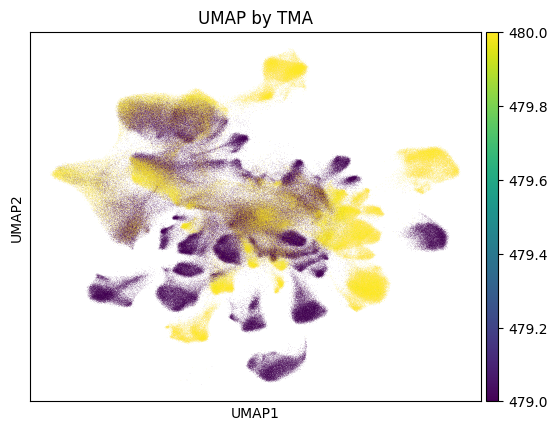

In [4]:
# Plot UMAP by TMA 
sc.pl.umap(adata, color = 'TMA', title = 'UMAP by TMA')

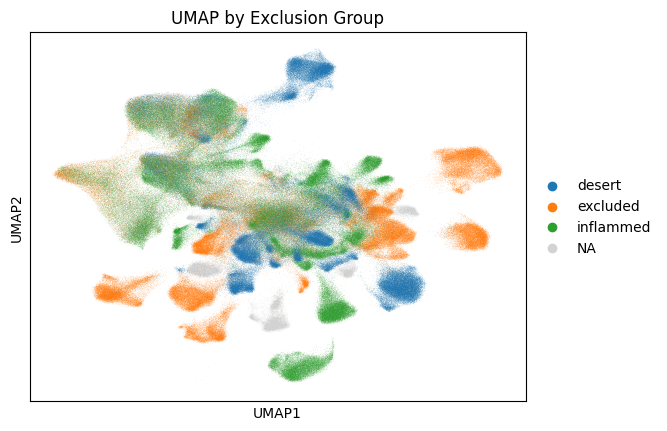

In [5]:
#Plot UMAP by Exclusion Group
sc.pl.umap(adata, color = 'ex_group', title = 'UMAP by Exclusion Group')


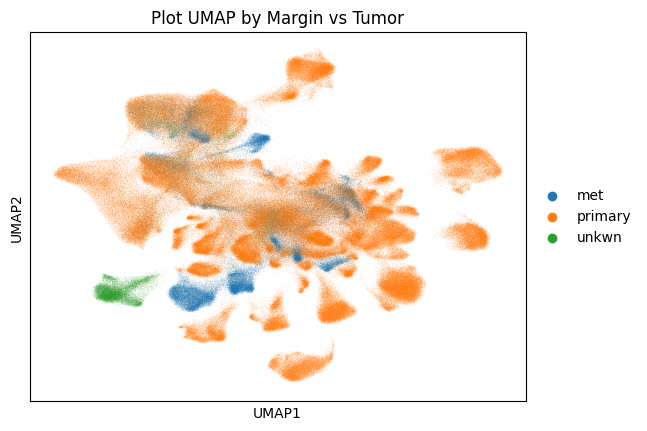

In [6]:
# Plot UMAP by Sample Site
sc.pl.umap(adata, color = 'sample site: primary vs met', title = 'Plot UMAP by Margin vs Tumor')

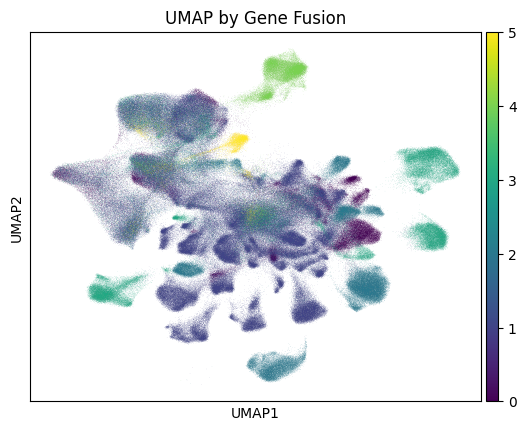

In [7]:
# Plot UMAP by Gene Fusion
sc.pl.umap(adata, color = 'NUT-fusion: 0 = unkwn; 1 = BRD4-NUT; 2 = BRD3-NUT; 3 = NSD3-NUT; 4 = ZNF532-NUT; 5 = ZNF592-NUT', title = 'UMAP by Gene Fusion')

In [8]:
adata.obs

,centroid_x,centroid_y,centroid_z,fov,cluster,volume,population,cell_num,Unnamed: 0,sample_num,...,treatment_status,OS_cat,sample_name,ex_group,cell_type_L2,cell_type_L1,cell_type_L0,cell_type_general,cell_type_L3,cell_id
0,7722.9272,18737.6400,17.120724,AD13,6,617.87110,605,cell_0_1,0,78.0,...,untreated,low,S16-2647 B2,inflammed,tumor,tumor,tumor,tumor,tumor,aaaaaceb-1
1,2909.9478,18718.9600,22.409761,AD5,5,1088.78910,54,cell_1_1,1,75.0,...,treated,low,BA12-166 A2,excluded,endothelial,endothelial,stromal,stromal,endothelial,aaaabdnf-1
2,5807.2960,2917.8280,23.243540,I10,6,998.61330,298,cell_3_1,3,7.0,...,untreated,medium,S14-81178 7A,NaN,tumor,tumor,tumor,tumor,tumor,aaaacmki-1
3,4885.3643,10135.5140,18.992750,S8,5,985.25390,106,cell_5_1,5,34.0,...,untreated,high,S15-105098 B1,desert,tumor,tumor,tumor,tumor,tumor,aaaajjch-1
5,4729.0880,10498.1470,21.474840,S8,9,2949.08200,624,cell_7_1,7,34.0,...,untreated,high,S15-105098 B1,desert,fibroblast,fibroblast,stromal,stromal,fibroblast,aaabbieb-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
831608,2604.8767,21193.6740,31.898947,AD5,3,440.41406,109,cell_731889_2,731889,99.0,...,unknown,high,10AH 4757 D,inflammed,tumor,tumor,tumor,tumor,tumor,oimghmpg-1
831609,7427.3174,6953.5290,24.069862,J13,5,663.81250,72,cell_731891_2,731891,32.0,...,unknown,medium,10-6031,desert,tumor,tumor,tumor,tumor,tumor,oimgigjp-1
831610,5241.6953,6966.5000,24.839272,J9,6,261.69530,58,cell_731892_2,731892,31.0,...,unknown,medium,10-6031,desert,tumor,tumor,tumor,tumor,tumor,oimgipho-1
831611,9604.6920,2242.9946,28.050556,C16,4,15548.53100,167,cell_731894_2,731894,13.0,...,treated,medium,BS20-28340 D11,inflammed,fibroblast,fibroblast,stromal,stromal,fibroblast,oimgkmih-1


In [9]:
df = adata.obs[['cell_id','cell_type_L3',]]

In [10]:
df.rename(columns={'cell_type_L3': 'group'}, inplace=True)

/var/folders/3p/7nndjfj95j1b_fk0h38c9_y80000gn/T/ipykernel_5984/3995666670.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'cell_type_L3': 'group'}, inplace=True)


In [11]:
print(df)

           cell_id        group
0       aaaaaceb-1        tumor
1       aaaabdnf-1  endothelial
2       aaaacmki-1        tumor
3       aaaajjch-1        tumor
5       aaabbieb-1   fibroblast
...            ...          ...
831608  oimghmpg-1        tumor
831609  oimgigjp-1        tumor
831610  oimgipho-1        tumor
831611  oimgkmih-1   fibroblast
831612  oimgmikk-1        tumor

[695260 rows x 2 columns]


In [12]:
df.to_csv('df_1.csv')

In [13]:
# Determine general cell types in dataset
print(adata.obs['cell_type_general'].unique())

['tumor', 'stromal', 'myeloid', 'lymphoid', 'epithelial']
Categories (5, object): ['myeloid', 'lymphoid', 'epithelial', 'stromal', 'tumor']


In [14]:
# Create subset of *only* tumor cells
tumor_mask = adata.obs['cell_type_general'] == 'tumor'

adata_tumor = adata[tumor_mask].copy()

In [15]:
# Preview columns of adata tumor subset
adata_tumor.obs

,centroid_x,centroid_y,centroid_z,fov,cluster,volume,population,cell_num,Unnamed: 0,sample_num,...,treatment_status,OS_cat,sample_name,ex_group,cell_type_L2,cell_type_L1,cell_type_L0,cell_type_general,cell_type_L3,cell_id
0,7722.9272,18737.6400,17.120724,AD13,6,617.87110,605,cell_0_1,0,78.0,...,untreated,low,S16-2647 B2,inflammed,tumor,tumor,tumor,tumor,tumor,aaaaaceb-1
2,5807.2960,2917.8280,23.243540,I10,6,998.61330,298,cell_3_1,3,7.0,...,untreated,medium,S14-81178 7A,NaN,tumor,tumor,tumor,tumor,tumor,aaaacmki-1
3,4885.3643,10135.5140,18.992750,S8,5,985.25390,106,cell_5_1,5,34.0,...,untreated,high,S15-105098 B1,desert,tumor,tumor,tumor,tumor,tumor,aaaajjch-1
7,2357.6548,3153.2700,23.555016,I4,3,754.80470,760,cell_10_1,10,5.0,...,untreated,medium,1621120 B,desert,tumor,tumor,tumor,tumor,tumor,aaabchbk-1
8,6157.0080,17428.2030,17.131866,AC11,0,427.50000,590,cell_11_1,11,70.0,...,untreated,medium,BS21-36819,excluded,tumor,tumor,tumor,tumor,tumor,aaabgdag-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
831604,2181.7856,10308.4370,26.101997,O4,5,402.11720,21,cell_731876_2,731876,50.0,...,unknown,medium,11015 IV B06,NaN,tumor,tumor,tumor,tumor,tumor,oimffgik-1
831608,2604.8767,21193.6740,31.898947,AD5,3,440.41406,109,cell_731889_2,731889,99.0,...,unknown,high,10AH 4757 D,inflammed,tumor,tumor,tumor,tumor,tumor,oimghmpg-1
831609,7427.3174,6953.5290,24.069862,J13,5,663.81250,72,cell_731891_2,731891,32.0,...,unknown,medium,10-6031,desert,tumor,tumor,tumor,tumor,tumor,oimgigjp-1
831610,5241.6953,6966.5000,24.839272,J9,6,261.69530,58,cell_731892_2,731892,31.0,...,unknown,medium,10-6031,desert,tumor,tumor,tumor,tumor,tumor,oimgipho-1


In [16]:
# Subset to 50k
adata_tumor_50k = sc.pp.subsample(adata_tumor, n_obs = 50000, random_state = 5, copy = True)
print(adata_tumor_50k)

AnnData object with n_obs × n_vars = 50000 × 423
    obs: 'centroid_x', 'centroid_y', 'centroid_z', 'fov', 'cluster', 'volume', 'population', 'cell_num', 'Unnamed: 0', 'sample_num', 'sample_id', 'sample_type', 'TMA', 'batch', 'log10_total_counts', 'leiden', 'density_status', 'atypical', 'deviation_score', 'log_lib_size', 'cell_type', 'TMA_ID', 'OS_days', 'survival sample date to death (days)', 'treatment_(0= no treatment before biopsy; 1=treatment before biopsy)', 'biopsy_site', 'biopsy_site_classification (0 = unkwn; 1 = head and neck; 2 = thoracic; 3 = non-head and neck or thoracic; 4 = LN)', 'sample site: primary vs met', 'primary site classification (0 = unkwn; 1 = head and neck; 2 = thoracic; 3 = non-head and neck or thoracic)', 'age_(yrs)', 'sex', 'PDL1 (TPS%)', 'PDL1: 0 = <1%; 1 = >=1%', 'NUT-fusion: 0 = unkwn; 1 = BRD4-NUT; 2 = BRD3-NUT; 3 = NSD3-NUT; 4 = ZNF532-NUT; 5 = ZNF592-NUT', 'note:', 'Registry participant? (YES/n)', 'NC registry ID', 'accession no.', 'treatment_status'

In [17]:
import decipher as dc
import scipy.sparse as sp

# Decipher requires raw integer counts in .X; use the 'counts' layer
adata_tumor_dc = adata_tumor_50k.copy()
counts = adata_tumor_dc.layers['counts'].copy()

if sp.issparse(counts):
    counts.data = counts.data.round().astype(int)
else:
    counts = counts.round().astype(int)
adata_tumor_dc.X = counts

In [18]:
# Lower learning rate
from decipher.tools._decipher import DecipherConfig
config = DecipherConfig(learning_rate=1e-3)

Epoch 16 (batch 703/703) | | train elbo: 240.02 (last epoch: 239.93) | val ll: 247.80:   2%|▏         | 16/1000 [01:25<1:27:29,  5.34s/it]2026-03-13 04:27:19,087 | INFO : Early stopping has been triggered.
2026-03-13 04:27:19,169 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-03-13 04:27:19,170 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-03-13 04:27:19,173 | INFO : Saving decipher model with run_id 2026-03-13-04-27-19-linear-brown-heap.


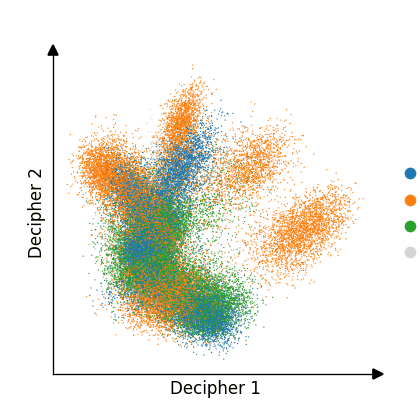

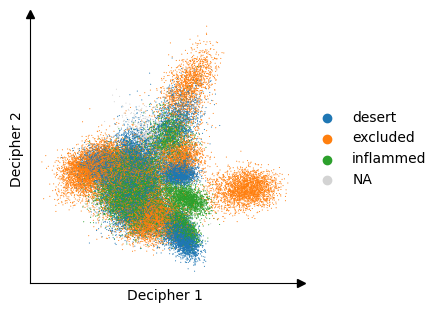

In [ ]:
# Train Decipher on tumor cells
decipher_model, val_losses = dc.tl.decipher_train(
    adata_tumor_dc,
    decipher_config = config,
    plot_kwargs={"color": "ex_group"},
)

In [20]:
adata_tumor_dc.obsm['decipher_v_seed1'] = adata_tumor_dc.obsm['decipher_v'].copy()

Epoch 15 (batch 703/703) | | train elbo: 238.70 (last epoch: 238.63) | val ll: 248.87:   2%|▏         | 15/1000 [01:14<1:21:24,  4.96s/it]2026-03-13 04:28:34,289 | INFO : Early stopping has been triggered.
2026-03-13 04:28:34,353 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-03-13 04:28:34,353 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-03-13 04:28:34,354 | INFO : Saving decipher model with run_id 2026-03-13-04-28-34-optimal-wary-glaze.


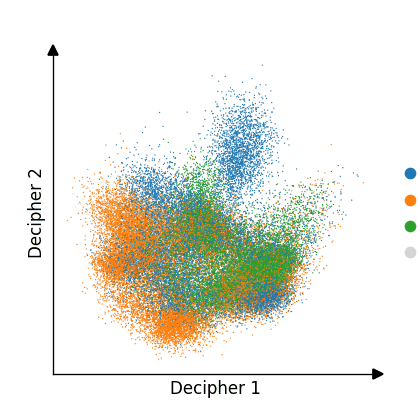

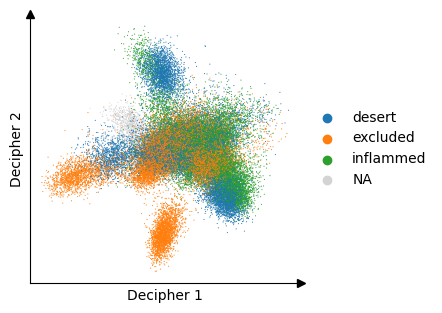

In [21]:
# 2nd Seed
config = DecipherConfig(learning_rate=1e-3, seed = 22)

# Train Decipher on tumor cells
decipher_model_s2, val_losses_s2 = dc.tl.decipher_train(
    adata_tumor_dc,
    decipher_config = config,
    plot_kwargs={"color": "ex_group"},
)

adata_tumor_dc.obsm['decipher_v_seed2'] = adata_tumor_dc.obsm['decipher_v'].copy()

Epoch 21 (batch 703/703) | | train elbo: 238.91 (last epoch: 238.95) | val ll: 250.10:   2%|▏         | 21/1000 [02:15<1:45:36,  6.47s/it]2026-03-13 04:30:50,934 | INFO : Early stopping has been triggered.
2026-03-13 04:30:51,014 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-03-13 04:30:51,014 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-03-13 04:30:51,015 | INFO : Saving decipher model with run_id 2026-03-13-04-30-51-spicy-olive-pastry.


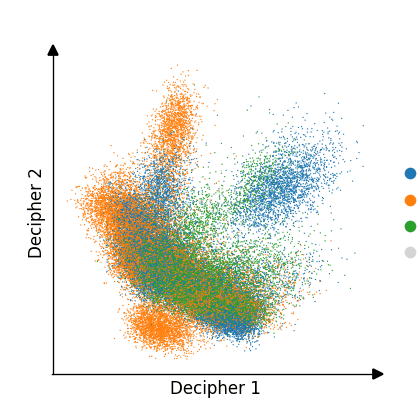

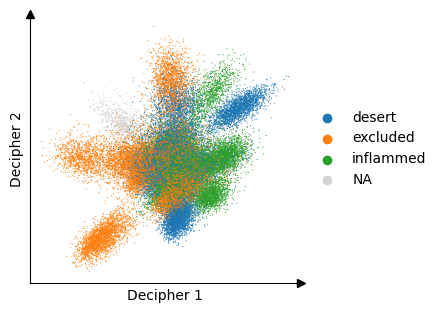

In [22]:
# 3rd Seed
config = DecipherConfig(learning_rate=1e-3, seed = 47)

# Train Decipher on tumor cells
decipher_model_s3, val_losses_s3 = dc.tl.decipher_train(
    adata_tumor_dc,
    decipher_config = config,
    plot_kwargs={"color": "ex_group"},
)

adata_tumor_dc.obsm['decipher_v_seed3'] = adata_tumor_dc.obsm['decipher_v'].copy()

Epoch 21 (batch 703/703) | | train elbo: 240.02 (last epoch: 240.03) | val ll: 247.62:   2%|▏         | 21/1000 [02:02<1:35:28,  5.85s/it]2026-03-13 04:32:54,803 | INFO : Early stopping has been triggered.
2026-03-13 04:32:54,866 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-03-13 04:32:54,866 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-03-13 04:32:54,867 | INFO : Saving decipher model with run_id 2026-03-13-04-32-54-fried-asphalt-relation.


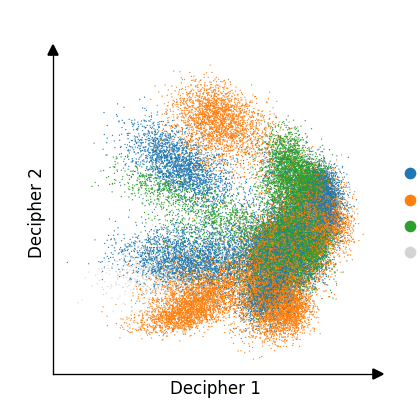

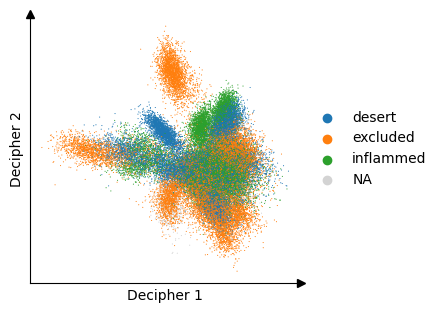

In [23]:
# 4th Seed
config = DecipherConfig(learning_rate=1e-3, seed = 225)

# Train Decipher on tumor cells
decipher_model_s4, val_losses_s4 = dc.tl.decipher_train(
    adata_tumor_dc,
    decipher_config = config,
    plot_kwargs={"color": "ex_group"},
)

adata_tumor_dc.obsm['decipher_v_seed4'] = adata_tumor_dc.obsm['decipher_v'].copy()

Epoch 22 (batch 703/703) | | train elbo: 238.41 (last epoch: 238.49) | val ll: 247.41:   2%|▏         | 22/1000 [01:45<1:18:00,  4.79s/it]2026-03-13 04:34:40,881 | INFO : Early stopping has been triggered.
2026-03-13 04:34:40,933 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-03-13 04:34:40,933 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-03-13 04:34:40,933 | INFO : Saving decipher model with run_id 2026-03-13-04-34-40-active-lively-pizza.


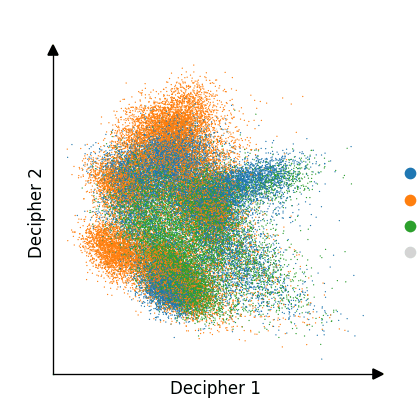

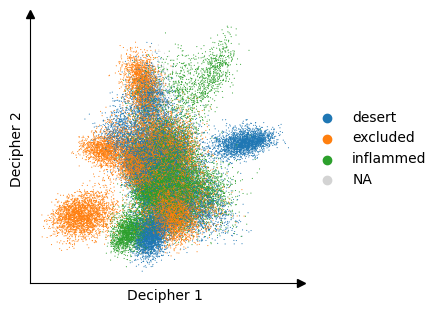

In [24]:
# 5th Seed
config = DecipherConfig(learning_rate=1e-3, seed = 5)

# Train Decipher on tumor cells
decipher_model_s5, val_losses_s5 = dc.tl.decipher_train(
    adata_tumor_dc,
    decipher_config = config,
    plot_kwargs={"color": "ex_group"},
)

adata_tumor_dc.obsm['decipher_v_seed5'] = adata_tumor_dc.obsm['decipher_v'].copy()

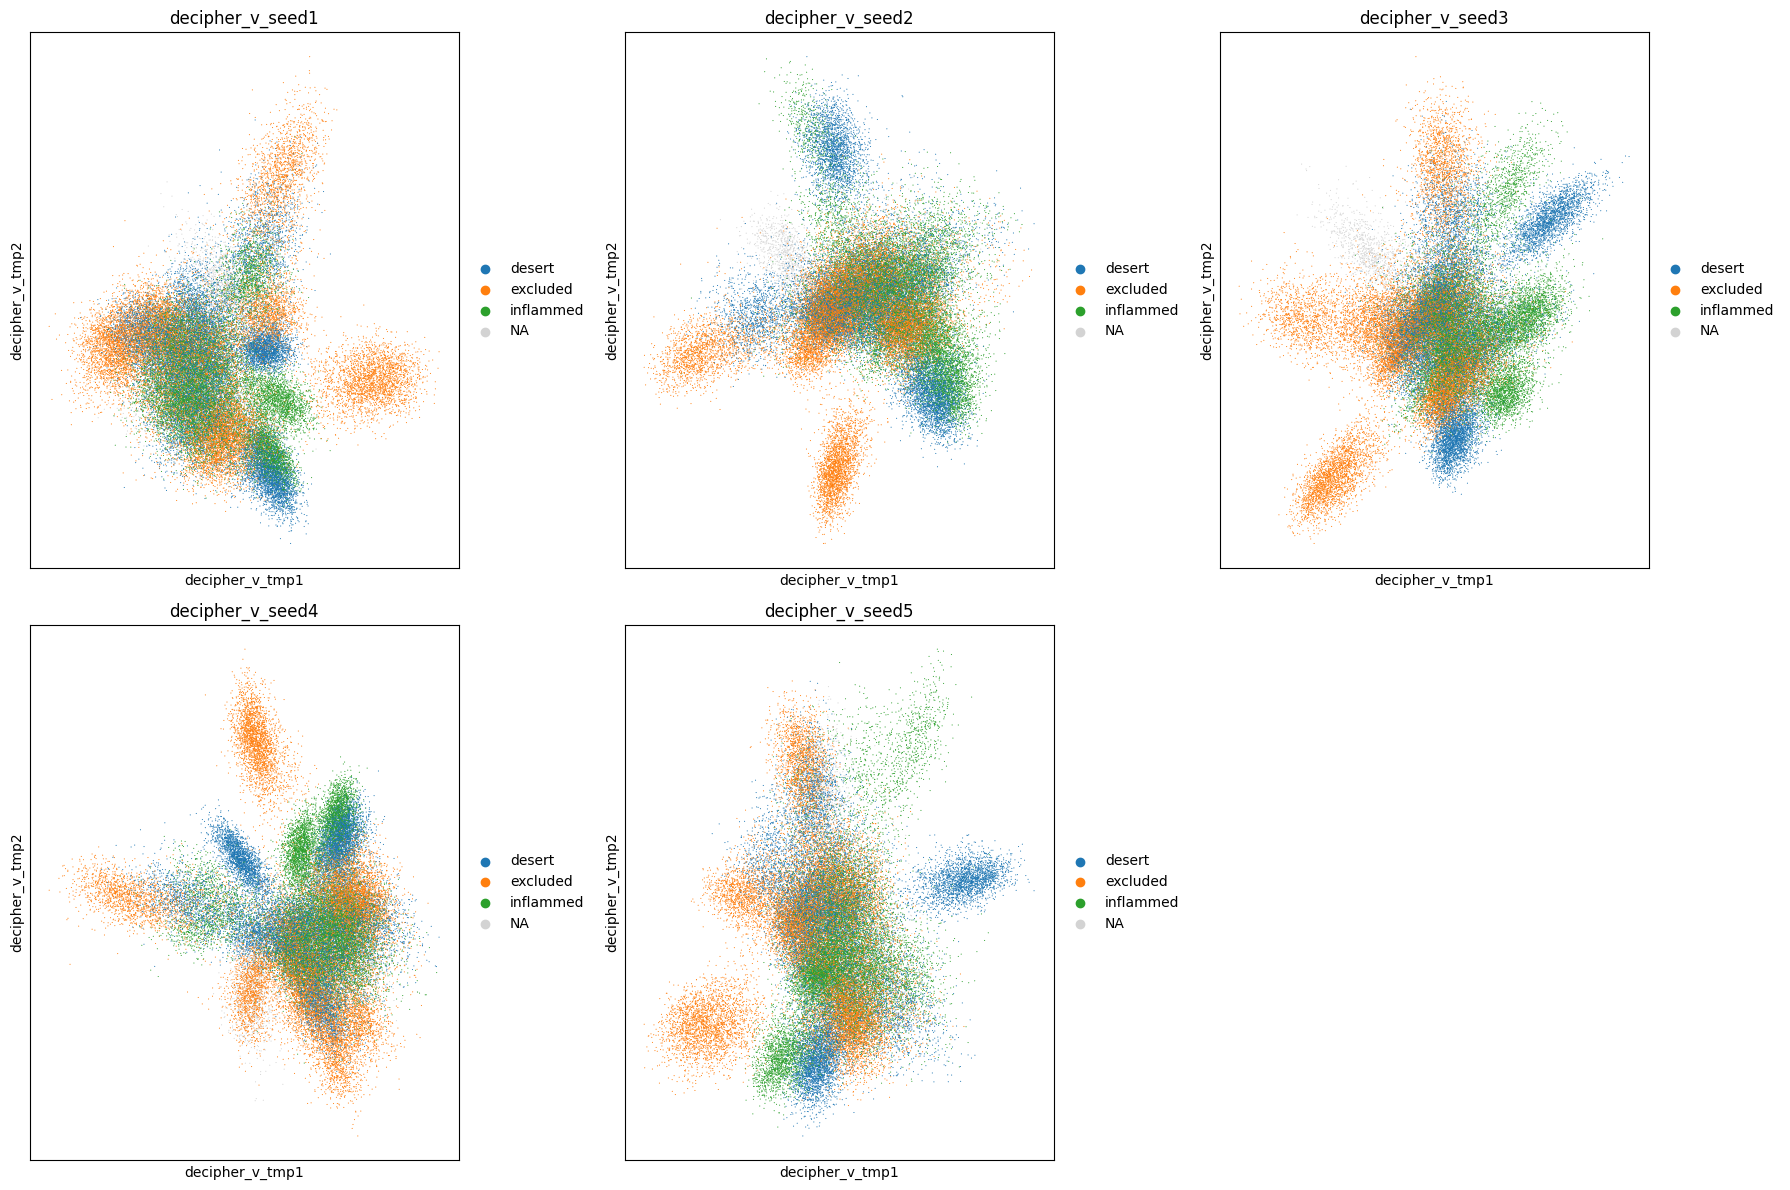

In [25]:
# Compare all 5
import matplotlib.pyplot as plt

seed_keys = ['decipher_v_seed1', 'decipher_v_seed2', 'decipher_v_seed3',
             'decipher_v_seed4', 'decipher_v_seed5']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for i, seed_key in enumerate(seed_keys):
    row, col = divmod(i, 3)
    adata_tumor_dc.obsm['decipher_v_tmp'] = adata_tumor_dc.obsm[seed_key]
    sc.pl.embedding(adata_tumor_dc, basis='decipher_v_tmp', color='ex_group',
                    ax=axes[row, col], show=False, title=seed_key)

axes[1, 2].set_visible(False)
plt.tight_layout()
plt.show()


So visually:

Proximity = transcriptional similarity — two dots close together means those two cells have similar gene expression patterns
Clusters = groups of cells sharing a transcriptional program
Spread = transcriptional heterogeneity within a group

In [26]:
# Full dataset 
adata_tumor_full = adata_tumor.copy()
counts = adata_tumor_full.layers['counts'].copy()
if sp.issparse(counts):
    counts.data = counts.data.round().astype(int)
else:
    counts = counts.round().astype(int)
adata_tumor_full.X = counts

Epoch 12 (batch 6945/6945) | | train elbo: 109118965886.63 (last epoch: 90801.45) | val ll: 1023.31:   1%|          | 12/1000 [12:03<16:32:22, 60.27s/it]2026-03-13 04:46:54,286 | INFO : Early stopping has been triggered.
2026-03-13 04:46:54,953 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-03-13 04:46:54,953 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-03-13 04:46:54,954 | INFO : Saving decipher model with run_id 2026-03-13-04-46-54-relaxed-navy-polytope.


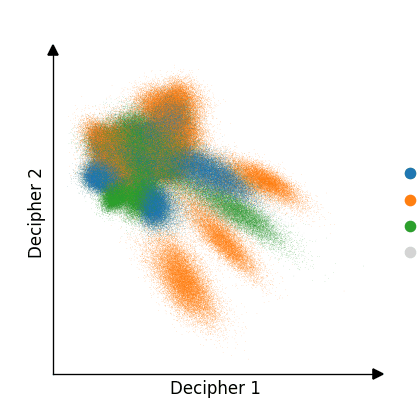

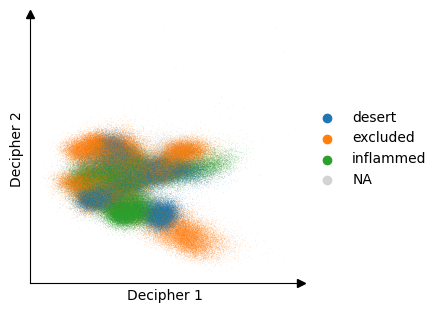

In [27]:
# Train on full data. Run 1: Seed = 10
config_full = DecipherConfig(learning_rate=5e-4, seed = 10)
decipher_model_full, val_losses_full = dc.tl.decipher_train(
    adata_tumor_full,
    decipher_config=config_full,
    plot_kwargs={"color": "ex_group"},
)

adata_tumor_full.obsm['decipher_v_full_s1'] = adata_tumor_full.obsm['decipher_v'].copy()

Epoch 12 (batch 6945/6945) | | train elbo: 244.18 (last epoch: 245.00) | val ll: 255.72:   1%|          | 12/1000 [10:44<14:43:50, 53.67s/it]2026-03-13 04:57:44,808 | INFO : Early stopping has been triggered.
2026-03-13 04:57:45,496 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-03-13 04:57:45,496 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-03-13 04:57:45,497 | INFO : Saving decipher model with run_id 2026-03-13-04-57-45-universal-white-edge.


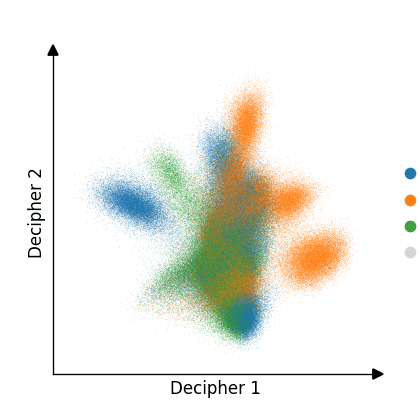

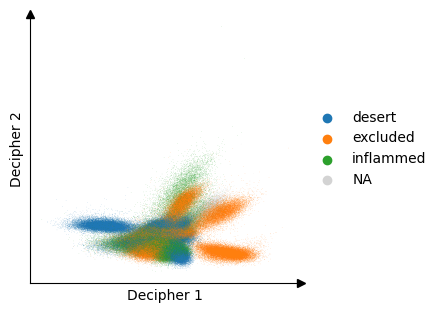

In [28]:
# Run 2: Seed = 304
config_full = DecipherConfig(learning_rate=5e-4, seed = 304)

decipher_model_full_s2, val_losses_full_s2 = dc.tl.decipher_train(
    adata_tumor_full,
    decipher_config=config_full,
    plot_kwargs={"color": "ex_group"},
)

adata_tumor_full.obsm['decipher_v_full_s2'] = adata_tumor_full.obsm['decipher_v'].copy()


Epoch 11 (batch 6945/6945) | | train elbo: 244.41 (last epoch: 5633.08) | val ll: 259.15:   1%|          | 11/1000 [10:14<15:20:52, 55.87s/it]2026-03-13 05:08:06,369 | INFO : Early stopping has been triggered.
2026-03-13 05:08:07,177 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-03-13 05:08:07,178 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-03-13 05:08:07,178 | INFO : Saving decipher model with run_id 2026-03-13-05-08-07-local-plum-stack.


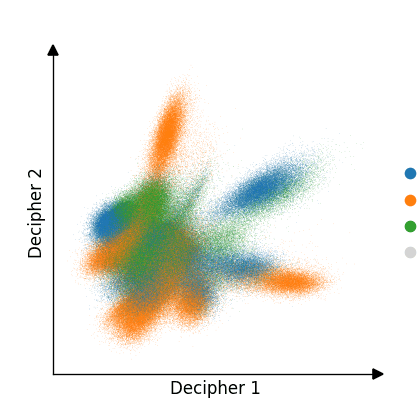

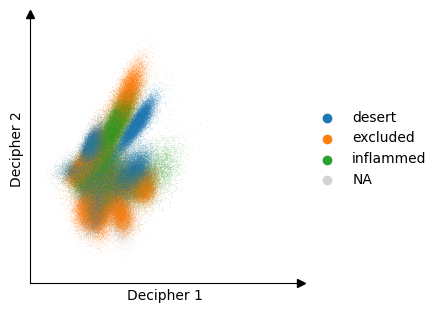

In [29]:
# Run 3: Seed = 42
config_full = DecipherConfig(learning_rate=5e-4, seed = 42)

decipher_model_full_s3, val_losses_full_s3 = dc.tl.decipher_train(
    adata_tumor_full,
    decipher_config=config_full,
    plot_kwargs={"color": "ex_group"},
)

adata_tumor_full.obsm['decipher_v_full_s3'] = adata_tumor_full.obsm['decipher_v'].copy()

Epoch 10 (batch 6945/6945) | | train elbo: 236.91 (last epoch: 236.10) | val ll: 250.28:   1%|          | 10/1000 [09:40<15:57:49, 58.05s/it]2026-03-13 05:17:55,230 | INFO : Early stopping has been triggered.
2026-03-13 05:17:55,984 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-03-13 05:17:55,985 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-03-13 05:17:55,985 | INFO : Saving decipher model with run_id 2026-03-13-05-17-55-delicious-tranquil-collision.


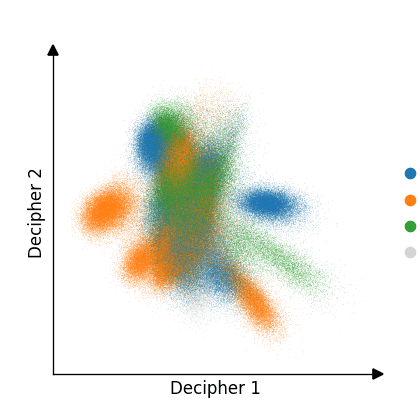

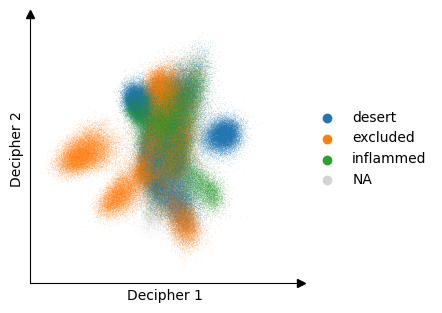

In [30]:
# Run 4: Seed = 21
config_full = DecipherConfig(learning_rate=5e-4, seed = 21)

decipher_model_full_s4, val_losses_full_s4 = dc.tl.decipher_train(
    adata_tumor_full,
    decipher_config=config_full,
    plot_kwargs={"color": "ex_group"},
)

adata_tumor_full.obsm['decipher_v_full_s4'] = adata_tumor_full.obsm['decipher_v'].copy()

Epoch 12 (batch 6945/6945) | | train elbo: 1973.04 (last epoch: 306.57) | val ll: 257.68:   1%|          | 12/1000 [11:06<15:14:33, 55.54s/it]2026-03-13 05:29:09,933 | INFO : Early stopping has been triggered.
2026-03-13 05:29:10,941 | INFO : Added `.obsm['decipher_v']`: the Decipher v space.
2026-03-13 05:29:10,941 | INFO : Added `.obsm['decipher_z']`: the Decipher z space.
2026-03-13 05:29:10,942 | INFO : Saving decipher model with run_id 2026-03-13-05-29-10-open-desert-parent.


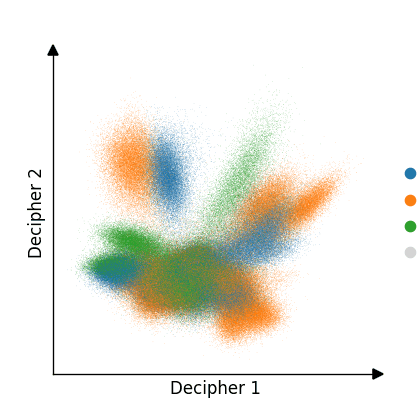

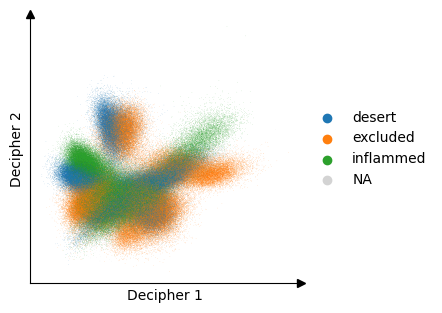

In [31]:
# Run 5: Seed = 53
config_full = DecipherConfig(learning_rate=5e-4, seed = 53)

decipher_model_full_s5, val_losses_full_s5 = dc.tl.decipher_train(
    adata_tumor_full,
    decipher_config=config_full,
    plot_kwargs={"color": "ex_group"},
)

adata_tumor_full.obsm['decipher_v_full_s5'] = adata_tumor_full.obsm['decipher_v'].copy()

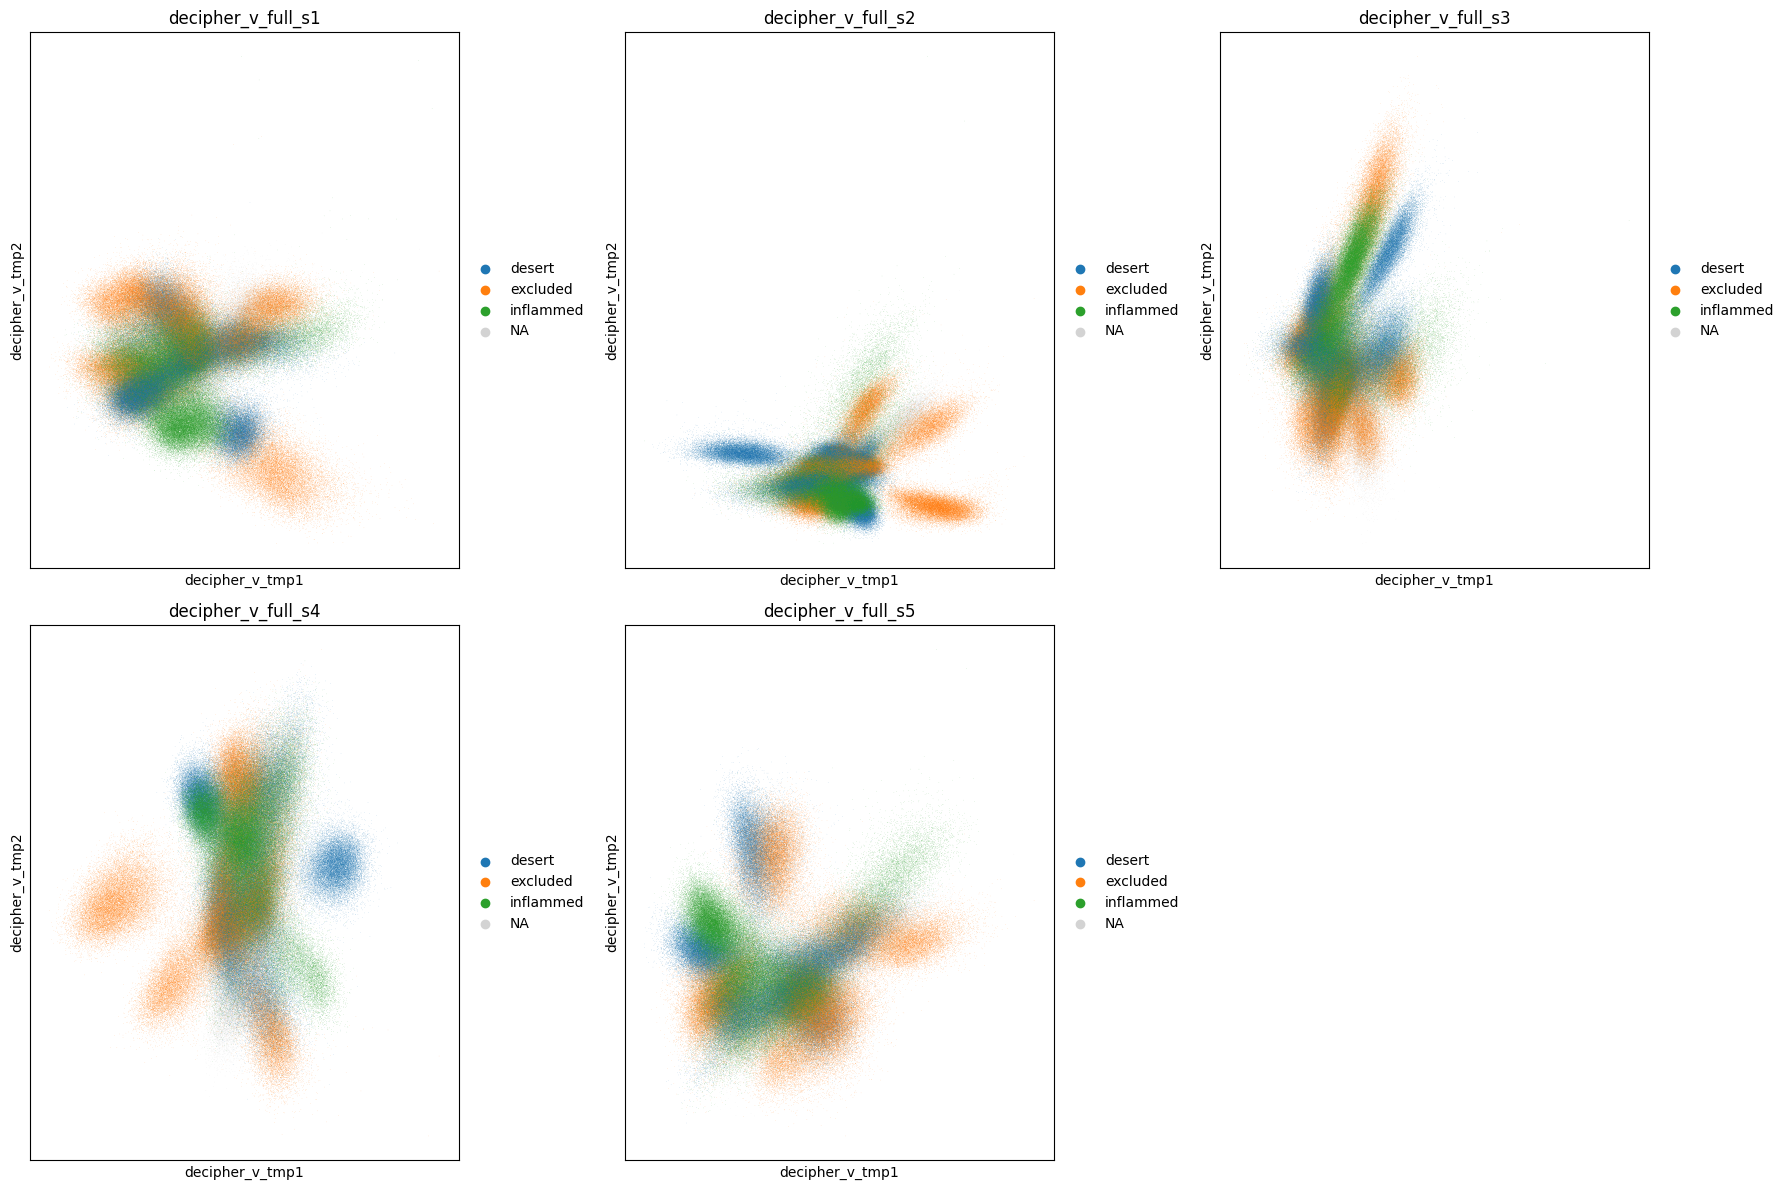

In [32]:
# Compare all 5
import matplotlib.pyplot as plt

seed_keys = ['decipher_v_full_s1', 'decipher_v_full_s2', 'decipher_v_full_s3',
             'decipher_v_full_s4', 'decipher_v_full_s5']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for i, seed_key in enumerate(seed_keys):
    row, col = divmod(i, 3)
    adata_tumor_full.obsm['decipher_v_tmp'] = adata_tumor_full.obsm[seed_key]
    sc.pl.embedding(adata_tumor_full, basis='decipher_v_tmp', color='ex_group',
                    ax=axes[row, col], show=False, title=seed_key)

axes[1, 2].set_visible(False)
plt.tight_layout()
plt.show()


In [33]:
#Checkpoint: Save all trained models
import scanpy as sc
adata_tumor_dc.write_h5ad('trained_models/adata_tumor_subset_decipher.h5ad')
adata_tumor_full.write_h5ad('trained_models/adata_tumor_full_decipher.h5ad')

In [34]:
# Load trained models
adata_tumor_dc = sc.read_h5ad('trained_models/adata_tumor_subset_decipher.h5ad')
adata_tumor_full = sc.read_h5ad('trained_models/adata_tumor_full_decipher.h5ad')

## Are clusters separating based on exclusion groups?

Yes. Across all 5 seeds, desert groups (blue) and inflammed groups (green) form tight,compact blobs. In contrast,  excluded groups spread out. Maybe this means that excluded-TME tumors cells have a wide range of gene expression patterns? Decipher axes represent tumor cell gene expression.

Another note: if it is separating based on exclusion groups, then there might be an associaton gene activity and tumor microenvironment. 


Because this pattern is seen consistently, that means Decipher is detecting some underlying structure. Note that for the full 493k dataset, desert and inflammed exclusion groups form sharper and more well-defined clusters compared to those in the subsetted 50k dataset

## Analysis of Gene Signatures

0 -0.048097726
1 -0.3479369


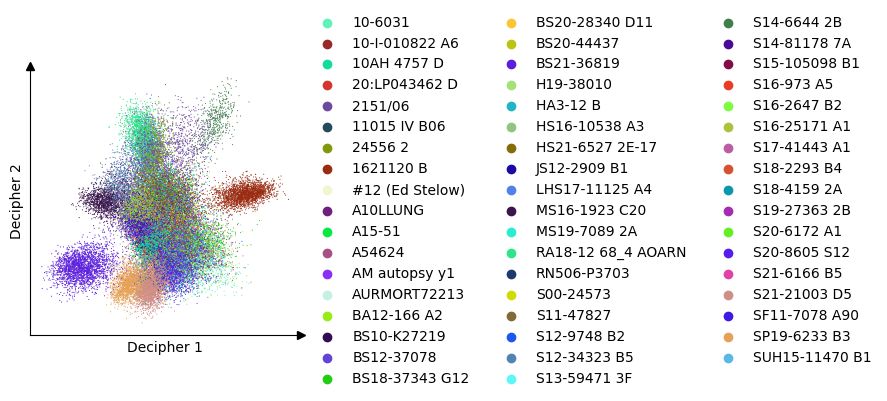

In [35]:
# Does batch separate in the Decipher space?
# Plot on v space
dc.pl.decipher(adata_tumor_dc, color='sample_id')

# Does batch correlate with v1?
import scipy.stats as stats

#Print average position on v1 axis
for batch in adata_tumor_dc.obs['batch'].unique():
    mask = adata_tumor_dc.obs['batch'] == batch
    print(batch, adata_tumor_dc.obsm['decipher_v'][mask, 0].mean())

In [55]:
# Gene List
import pandas as pd
diff_marker_df = pd.read_excel('/Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/Data/tumor_differentiation_markers.xlsx', sheet_name = 'undiff v diff markers NC')

undiff_gene_list = diff_marker_df.loc[:,'undiff']
diff_gene_list = diff_marker_df.loc[:,'diff']

In [69]:
print(undiff_gene_list)
print(diff_gene_list)

0      TP63
1       MYC
2      SOX2
3      EZH2
4      EZH1
5      PVT1
6    CASC19
7       MAX
8       ID1
9     MKI67
Name: undiff, dtype: object
0     KRT14
1      KRT5
2     KRT10
3    CDKN1A
4    CDKN1C
5       NaN
6       NaN
7       NaN
8       NaN
9       NaN
Name: diff, dtype: object


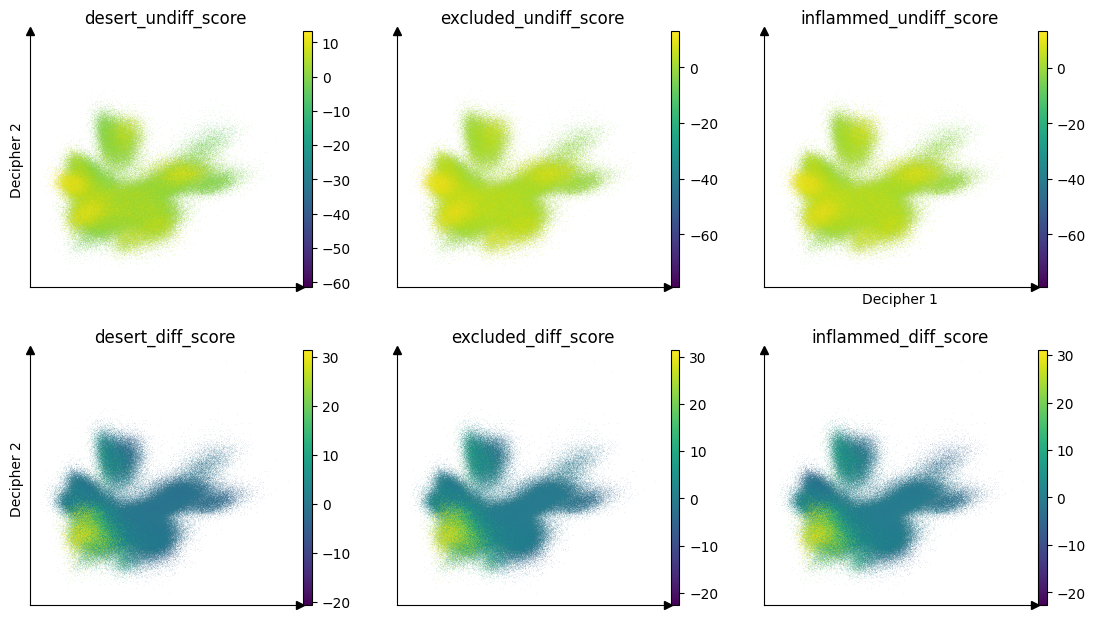

In [73]:
groups = adata_tumor_full.obs['ex_group'].cat.categories

for g in groups:
    mask = adata_tumor_full.obs['ex_group'] == g
    adata_group = adata_tumor_full[mask].copy()
    
    sc.tl.score_genes(adata_group, gene_list=undiff_gene_list, score_name='undiff_score')
    sc.tl.score_genes(adata_group, gene_list=diff_gene_list, score_name='diff_score')
    
    adata_tumor_full.obs.loc[mask, f'{g}_undiff_score'] = adata_group.obs['undiff_score'].values
    adata_tumor_full.obs.loc[mask, f'{g}_diff_score'] = adata_group.obs['diff_score'].values

# Cells not in a group will be NaN
color_list = [f'{g}_undiff_score' for g in groups] + [f'{g}_diff_score' for g in groups]
dc.pl.decipher(adata_tumor_full, color=color_list, ncols=3)
plt.show()


['centroid_x', 'centroid_y', 'centroid_z', 'fov', 'cluster', 'volume', 'population', 'cell_num', 'Unnamed: 0', 'sample_num', 'sample_id', 'sample_type', 'TMA', 'batch', 'log10_total_counts', 'leiden', 'density_status', 'atypical', 'deviation_score', 'log_lib_size', 'cell_type', 'TMA_ID', 'OS_days', 'survival sample date to death (days)', 'treatment_(0= no treatment before biopsy; 1=treatment before biopsy)', 'biopsy_site', 'biopsy_site_classification (0 = unkwn; 1 = head and neck; 2 = thoracic; 3 = non-head and neck or thoracic; 4 = LN)', 'sample site: primary vs met', 'primary site classification (0 = unkwn; 1 = head and neck; 2 = thoracic; 3 = non-head and neck or thoracic)', 'age_(yrs)', 'sex', 'PDL1 (TPS%)', 'PDL1: 0 = <1%; 1 = >=1%', 'NUT-fusion: 0 = unkwn; 1 = BRD4-NUT; 2 = BRD3-NUT; 3 = NSD3-NUT; 4 = ZNF532-NUT; 5 = ZNF592-NUT', 'note:', 'Registry participant? (YES/n)', 'NC registry ID', 'accession no.', 'treatment_status', 'OS_cat', 'sample_name', 'ex_group', 'cell_type_L2', 'c

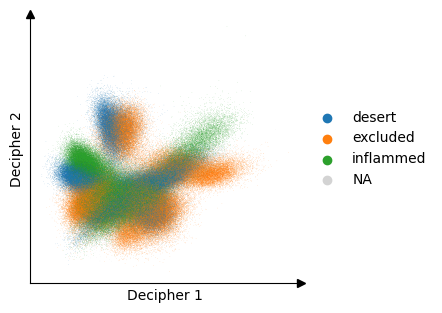

In [68]:
print(adata_tumor_full.obs.columns.tolist())

print(adata_tumor_full.obs[['ex_group', 'desert_diff_score', 'excluded_diff_score', 'inflammed_diff_score']].head(20))


dc.pl.decipher(adata_tumor_full, color='ex_group')
plt.show()

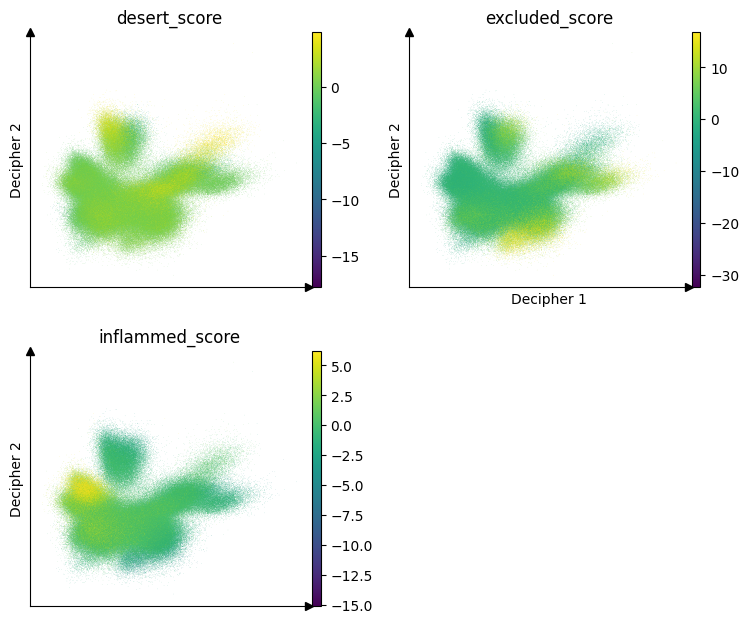

['HLA-B', 'ACTA2', 'MX1', 'STAT3', 'JUN', 'CD44', 'DGKA', 'CEACAM1', 'IRF1', 'IDO1', 'BCL2', 'IL18', 'VCAN', 'NFE2L2', 'SPARCL1', 'IFIT3', 'IFITM3', 'NELL2', 'EPCAM', 'SMAD3']


In [ ]:
#Closer look at top genes

#Create a 50k subset — inherits decipher uns (run_id_history, config) from adata_tumor_dc
# adata_subset = sc.pp.subsample(adata_tumor_dc, n_obs=50000, copy=True)

# all_run_ids = adata_tumor_full.uns["decipher"]["run_id_history"]
# run_ids_full = [r for r in all_run_ids if r.startswith("2026-03-04")]
# print(run_ids_today)  # verify before running

# for run_id in run_ids_full:
#     adata_tumor_full.uns["decipher"]["run_id"] = run_id
    
#     # Double check what this does
#     dc.tl.decipher_and_gene_covariance(adata_tumor_full)
    
#     gene_cov = adata_tumor_full.varm['decipher_v_gene_covariance']  # shape: (n_genes, n_v_dims)
#     gene_names = adata_tumor_full.var_names
    
#     print(f"\n=== {run_id} ===")
#     for v_dim in range(gene_cov.shape[1]):
#         top_idx = np.argsort(gene_cov[:, v_dim])[-10:][::-1]      # positive end
#         bot_idx = np.argsort(gene_cov[:, v_dim])[:10]              # negative end
#         print(f"v{v_dim+1} differentiated end: {list(gene_names[top_idx])}")
#         print(f"v{v_dim+1} undifferentiated end: {list(gene_names[bot_idx])}")

#Way I want to do this is 
#https://scanpy.readthedocs.io/en/stable/generated/scanpy.tl.score_genes.html

#also look at z scores and map

#Get Friday

# import scanpy as sc
# sc.tl.score_genes(adata_tumor_full)

# rank_genes_groups is already in adata_tumor_full.uns
# If you need to recompute it on the tumor subset grouped by ex_group:
sc.tl.rank_genes_groups(adata_tumor_full, groupby='ex_group', method='wilcoxon', layer = 'log_counts')


n_top = 20
groups = adata_tumor_full.obs['ex_group'].cat.categories

for group in groups:
    top_genes = sc.get.rank_genes_groups_df(adata_tumor_full, group=group)\
                  .head(n_top)['names'].tolist()
    sc.tl.score_genes(adata_tumor_full, gene_list=top_genes, score_name=f'{group}_score')

dc.pl.decipher(adata_tumor_full, color=[f'{g}_score' for g in groups])
plt.show()

print(top_genes)


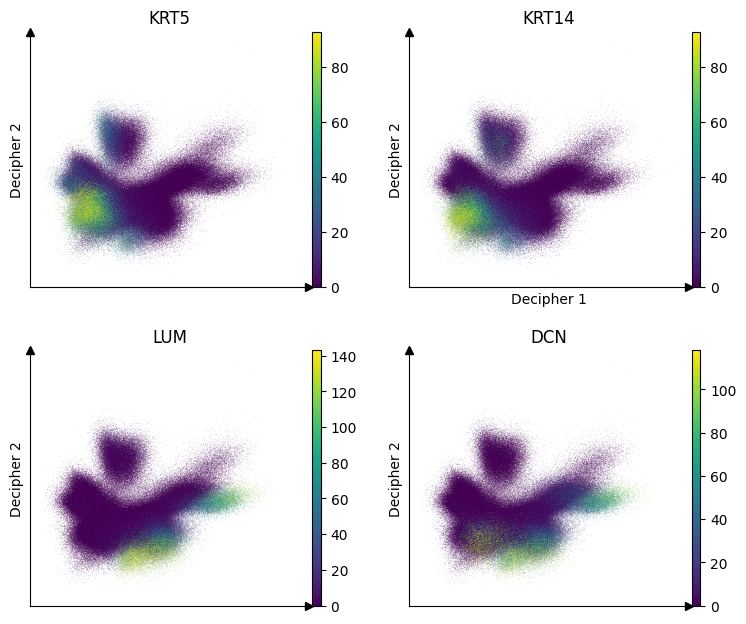

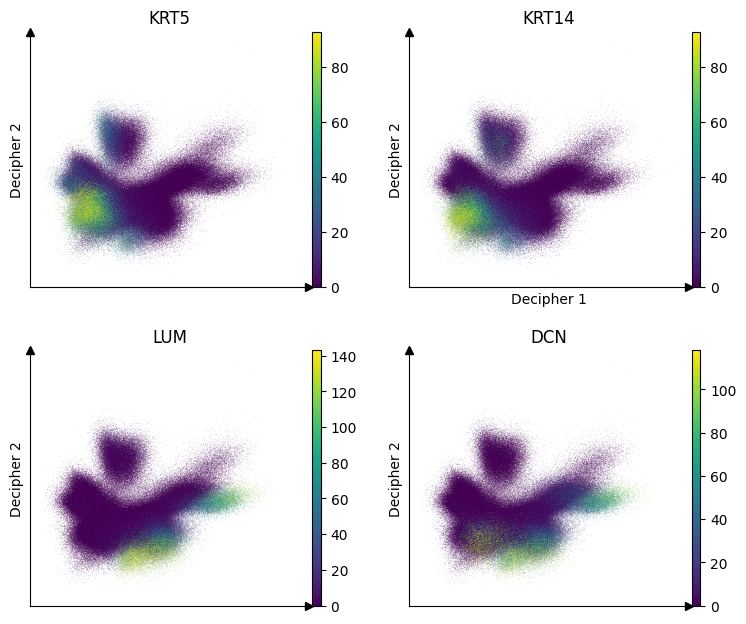

In [ ]:
# Show the differentiation gradient visually
dc.pl.decipher(adata_tumor_full, color=['KRT5', 'KRT14', 'LUM', 'DCN'])


## Look at gene signatures - Summary

Coloring by batch on v space gives fairly well mixing. However, the average position for batch 1 cells is -0.348 is skewed towards the differentiation axis. Note the existence of a blue "blob" on the right. This could be a batch effect. 

Looking at the top genes, it seems like v1 is the differentiation axis. Undifferentiated ends singled out MYC, LUM, DCN, which are markers of mesenchymal cells. Different ends singled out KRT4 and KRT14, which are  genes for keratin, commonly associated with squamous cells. Clear differentiation axis if we're looking at the genes. 

v2's top genes are ACTB, NOTCH1, and ID4, STMN1, FAP, and MYC. NOTCH1 associated with squamous differentiation, but ID4 blocks differentiation. Not sure what to make of this tbh

## Map Sample ID

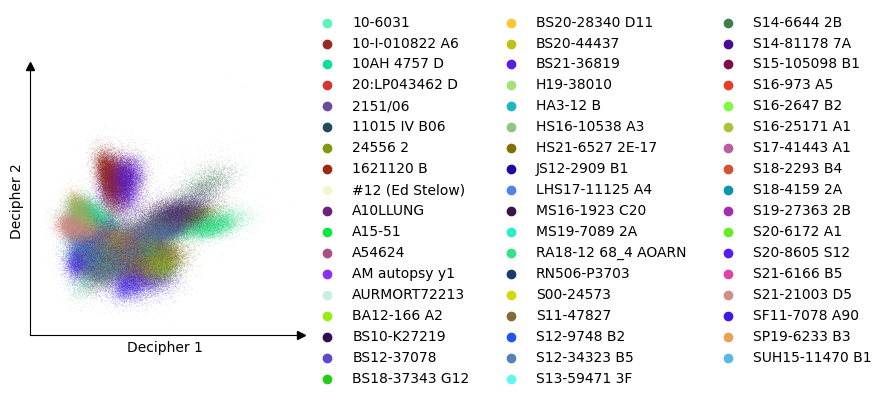

In [ ]:
dc.pl.decipher(adata_tumor_full, color='sample_id')
plt.show()


## Tumor Type Sample vs Margin

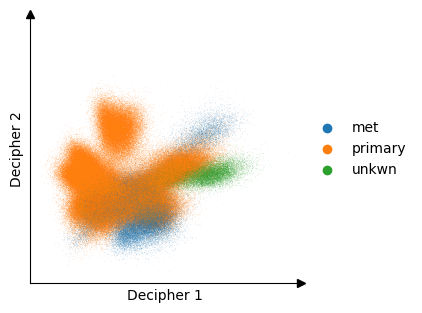

In [ ]:
dc.pl.decipher(adata_tumor_full, color='sample site: primary vs met')

# Found in sample type column
# Motivation: lot of covariates 
# look at center vs margin (especially true for excluded) --> does this drive expression?

# Know what the batch is and what to correct for

plt.show()


## Looking at Fusion Group

In [2]:
adata_tumor_full.obs[NUT-fusion] = adata_tumor_full.obs[NUT-fusion].astype('category')
dc.pl.decipher(adata_tumor_full, color=NUT-fusion)
plt.show()

NameError: name 'adata_tumor_full' is not defined

Are clusters separating based on exclusion groups

Look at gene signatures 

 - ideally with batch correction, we should see clear differentiation axis --> undifferentiated to differentiated

Map sample ID

Tumor type sample vs margin

Look at fusion group

Goals for next week:
Look at cluster = any relaion to correlates??

Run multiple seeds on dataset

Run through decipher tutorial

Slideshow of Decipher
- Read paper 

Present theory on how to do batch correction

Look at clusters --> similar to Leiden clusters
dc.tl.cell_clusters(adata)
dc.pl.decipher(adata, ["decipher_clusters"], legend_loc="on data");

Look for 1:1 clustering! Strong implication that batch effects tie directly to that variable
- Identically, differentiated vs undifferentiated 